In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, shapiro, ttest_ind, mannwhitneyu


In [3]:
df = pd.read_csv("education_dropout.csv", skipinitialspace=True)

# Shape of dataset
print("Shape:", df.shape)

# First 5 rows
df.head()

# Column names
print(df.columns.tolist())

Shape: (15000, 36)
['student_id  ', 'age', 'gender    ', 'first_generation_college', 'international_student', 'residency_status', 'high_school_gpa', 'sat_score', 'act_score', 'advanced_courses_taken', 'extracurricular_activities', 'major           ', 'enrollment_status', 'semester_credits', 'admission_type', 'starting_semester', 'family_income', 'financial_aid_received', 'pell_grant_eligible (scholarship)', 'student_loan_amount', 'has_campus_job', 'current_gpa', 'credits_completed', 'courses_failed', 'courses_withdrawn', 'attendance_rate', 'study_hours_per_week', 'library_visits_per_month', 'tutoring_sessions_attended', 'advisor_meetings', 'clubs_joined', 'living_arrangement', 'has_disability', 'distance_from_campus_miles', 'work_hours_per_week', 'dropped_out']


In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Verify
print(df.columns)

Index(['student_id', 'age', 'gender', 'first_generation_college',
       'international_student', 'residency_status', 'high_school_gpa',
       'sat_score', 'act_score', 'advanced_courses_taken',
       'extracurricular_activities', 'major', 'enrollment_status',
       'semester_credits', 'admission_type', 'starting_semester',
       'family_income', 'financial_aid_received',
       'pell_grant_eligible_(scholarship)', 'student_loan_amount',
       'has_campus_job', 'current_gpa', 'credits_completed', 'courses_failed',
       'courses_withdrawn', 'attendance_rate', 'study_hours_per_week',
       'library_visits_per_month', 'tutoring_sessions_attended',
       'advisor_meetings', 'clubs_joined', 'living_arrangement',
       'has_disability', 'distance_from_campus_miles', 'work_hours_per_week',
       'dropped_out'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   student_id                         15000 non-null  object 
 1   age                                15000 non-null  int64  
 2   gender                             15000 non-null  object 
 3   first_generation_college           15000 non-null  object 
 4   international_student              15000 non-null  object 
 5   residency_status                   15000 non-null  object 
 6   high_school_gpa                    15000 non-null  float64
 7   sat_score                          14250 non-null  float64
 8   act_score                          15000 non-null  int64  
 9   advanced_courses_taken             15000 non-null  int64  
 10  extracurricular_activities         15000 non-null  int64  
 11  major                              15000 non-null  obj

In [6]:
# convert hidden missing value to NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

In [7]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing %", ascending=False)

,Missing Count,Missing %
sat_score,750,5.0
current_gpa,750,5.0
attendance_rate,750,5.0


In [8]:
df['dropped_out'].value_counts()

dropped_out
No     9722
Yes    5278
Name: count, dtype: int64

In [9]:
df['dropped_out'] = df['dropped_out'].map({'Yes': 1, 'No': 0})

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['age', 'high_school_gpa', 'sat_score', 'act_score',
       'advanced_courses_taken', 'extracurricular_activities',
       'semester_credits', 'student_loan_amount', 'current_gpa',
       'credits_completed', 'courses_failed', 'courses_withdrawn',
       'attendance_rate', 'study_hours_per_week', 'library_visits_per_month',
       'tutoring_sessions_attended', 'advisor_meetings', 'clubs_joined',
       'distance_from_campus_miles', 'work_hours_per_week', 'dropped_out'],
      dtype='object')
Categorical Columns: Index(['student_id', 'gender', 'first_generation_college',
       'international_student', 'residency_status', 'major',
       'enrollment_status', 'admission_type', 'starting_semester',
       'family_income', 'financial_aid_received',
       'pell_grant_eligible_(scholarship)', 'has_campus_job',
       'living_arrangement', 'has_disability'],
      dtype='object')


In [11]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [12]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


In [14]:
df.describe()

,age,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,semester_credits,student_loan_amount,current_gpa,credits_completed,...,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,distance_from_campus_miles,work_hours_per_week,dropped_out
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,19.860533,3.287937,1151.856333,23.558733,2.998667,2.508533,13.580200,14962.108667,2.878657,41.503267,...,0.489533,77.734027,11.409267,4.014667,1.988133,1.507133,1.487467,14.430467,9.264800,0.351867
std,2.521330,0.461853,144.736379,3.919435,1.727599,1.593684,4.055301,15161.711834,0.650274,35.875932,...,0.695933,12.907042,11.673950,2.023015,1.399568,1.236521,1.217679,14.847168,9.142114,0.477569
min,17.000000,2.000000,800.000000,16.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,...,0.000000,13.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.970000,1057.000000,21.000000,2.000000,1.000000,12.000000,4273.000000,2.450000,12.000000,...,0.000000,70.200000,3.000000,3.000000,1.000000,1.000000,1.000000,4.000000,2.000000,0.000000
50%,20.000000,3.310000,1153.000000,23.000000,3.000000,2.000000,15.000000,10188.000000,2.900000,31.000000,...,0.000000,79.800000,8.000000,4.000000,2.000000,1.000000,1.000000,10.000000,6.000000,0.000000
75%,22.000000,3.640000,1247.000000,26.000000,4.000000,3.000000,18.000000,20691.250000,3.330000,62.000000,...,1.000000,87.400000,16.000000,5.000000,3.000000,2.000000,2.000000,21.000000,13.000000,1.000000
max,31.000000,4.000000,1600.000000,36.000000,11.000000,10.000000,18.000000,173123.000000,4.000000,120.000000,...,5.000000,99.900000,60.000000,15.000000,9.000000,9.000000,8.000000,100.000000,40.000000,1.000000


In [15]:
std_dev = df[num_cols].std().sort_values(ascending=False)

print("Standard Deviation:\n", std_dev)

Standard Deviation:
 student_loan_amount           15161.711834
sat_score                       144.736379
credits_completed                35.875932
distance_from_campus_miles       14.847168
attendance_rate                  12.907042
study_hours_per_week             11.673950
work_hours_per_week               9.142114
semester_credits                  4.055301
act_score                         3.919435
age                               2.521330
library_visits_per_month          2.023015
advanced_courses_taken            1.727599
extracurricular_activities        1.593684
tutoring_sessions_attended        1.399568
advisor_meetings                  1.236521
clubs_joined                      1.217679
courses_failed                    0.900525
courses_withdrawn                 0.695933
current_gpa                       0.650274
dropped_out                       0.477569
high_school_gpa                   0.461853
dtype: float64


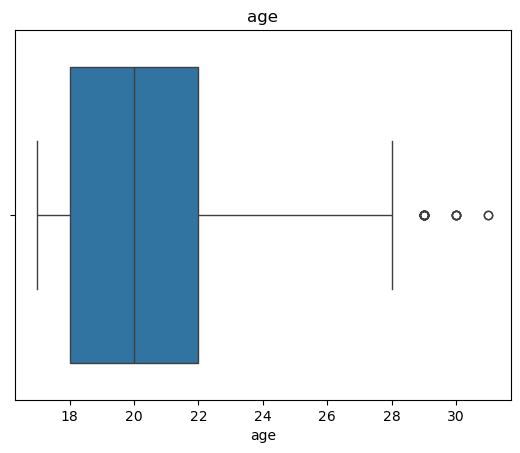

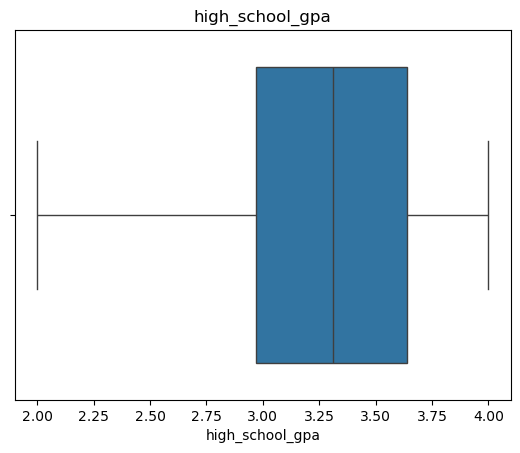

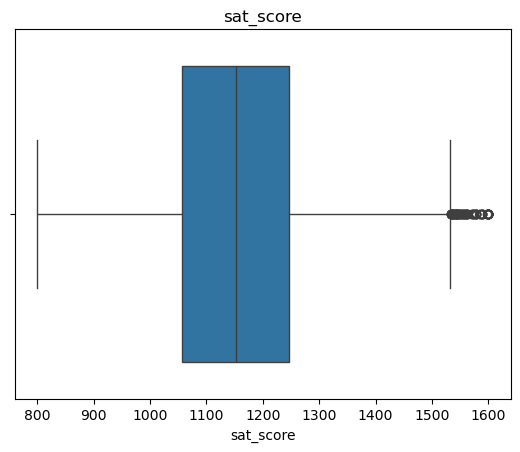

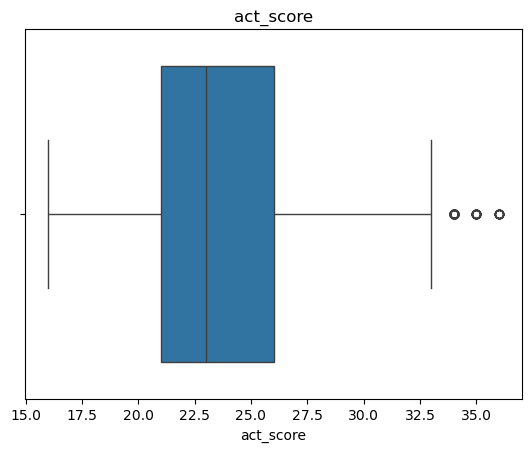

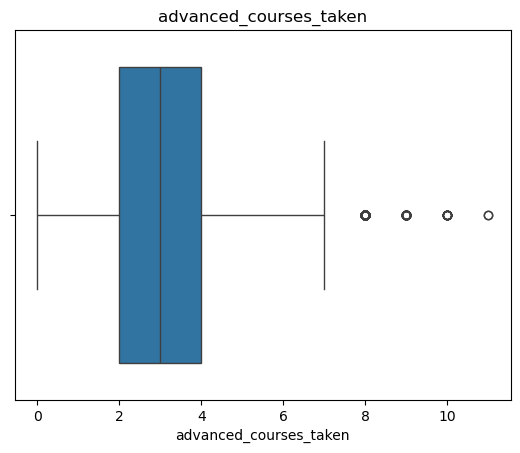

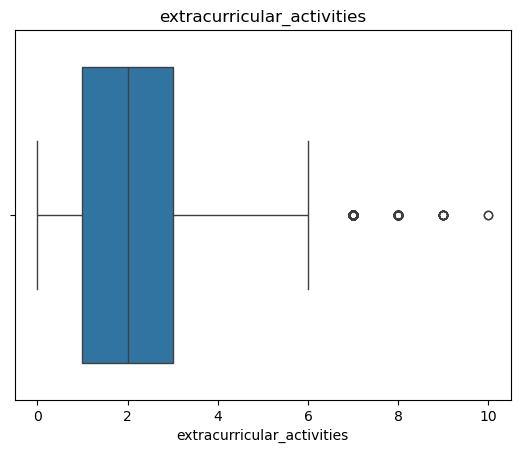

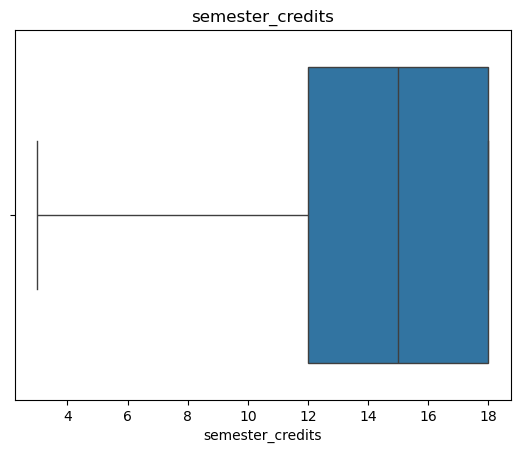

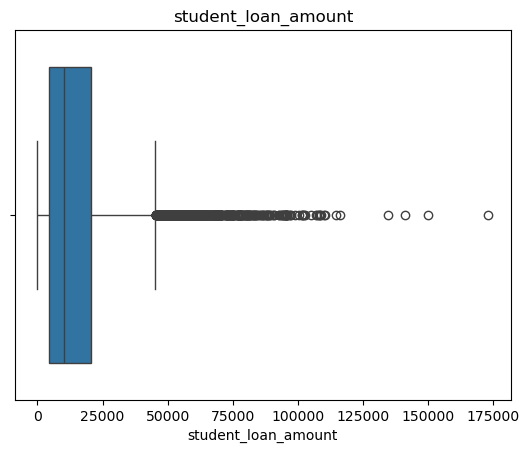

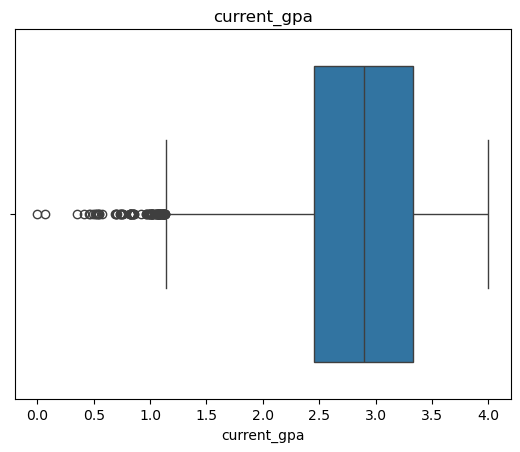

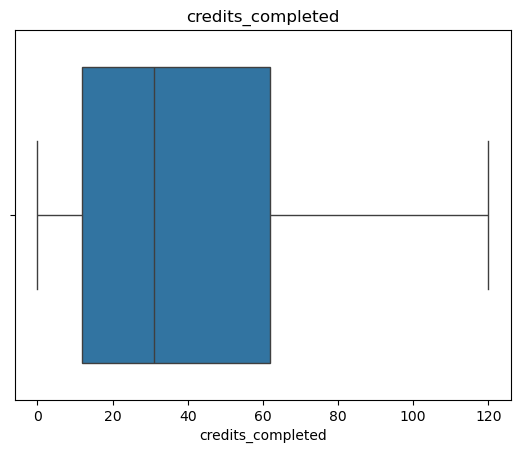

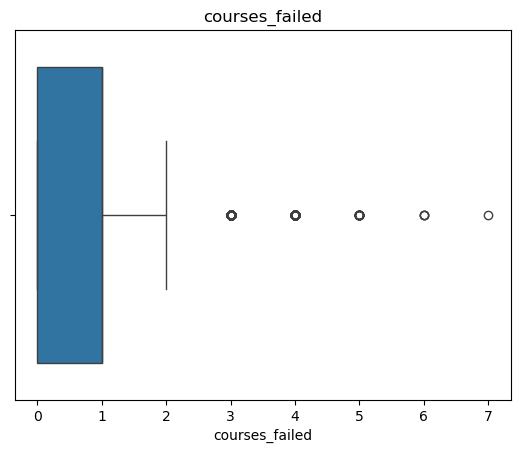

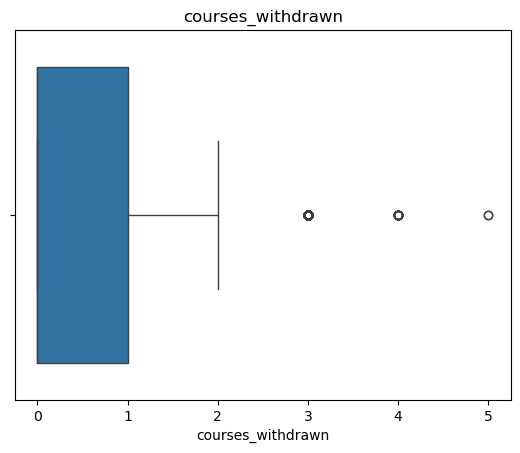

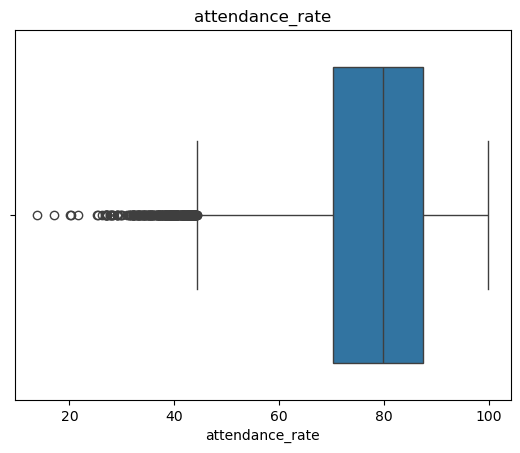

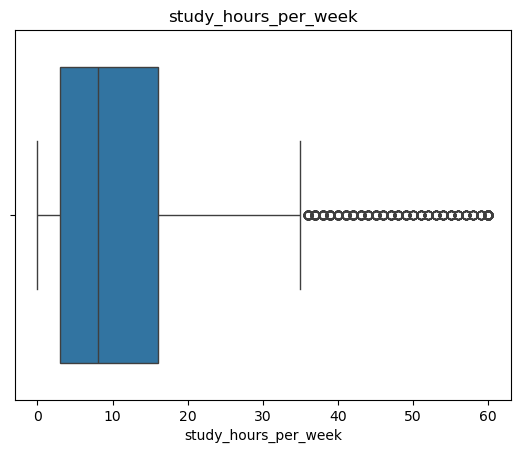

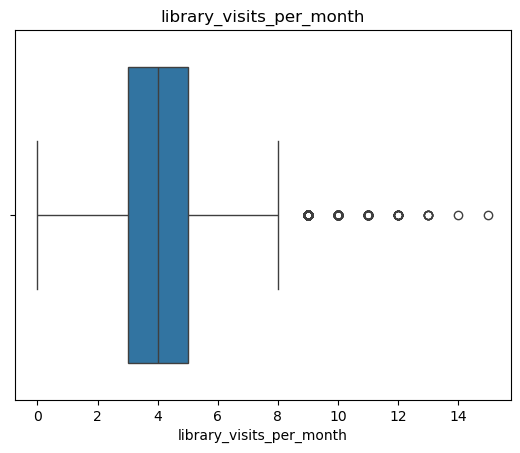

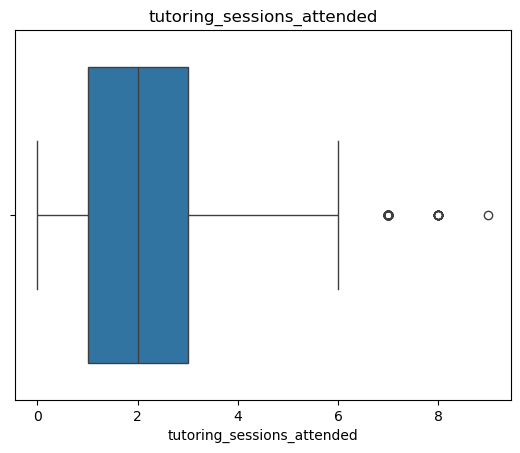

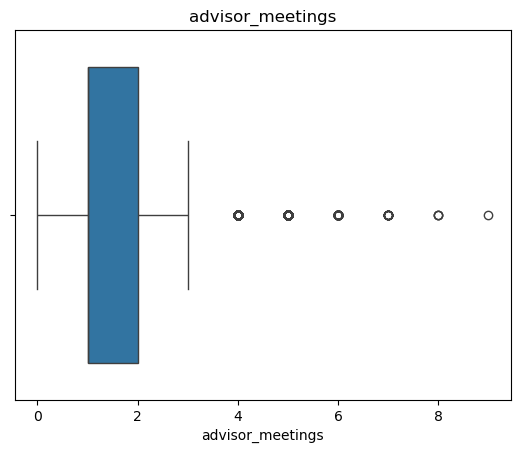

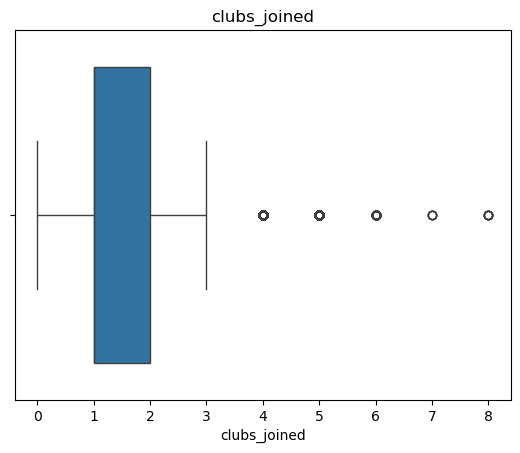

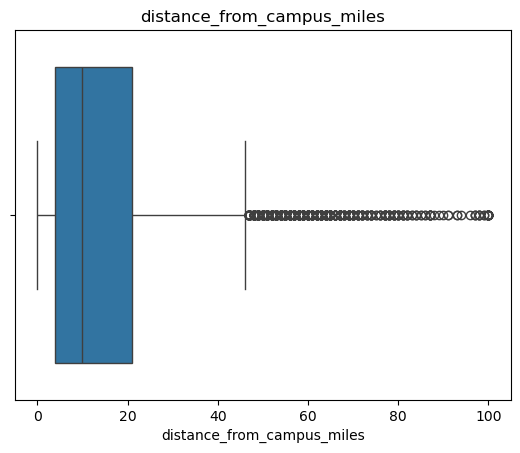

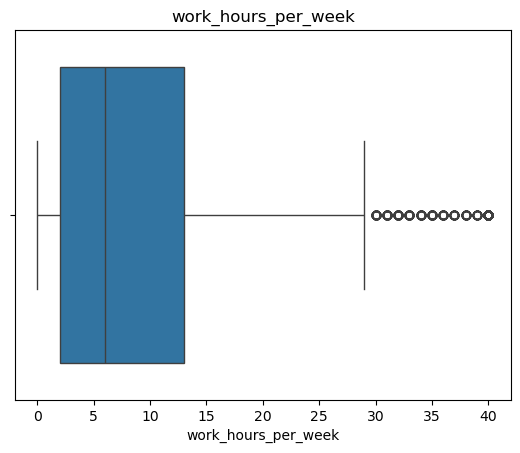

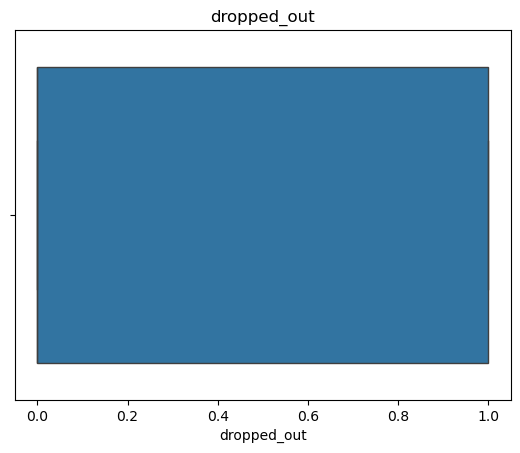

In [16]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [18]:
df.head()
df.shape

(15000, 36)

Hypothesis - 1

Students with lower GPA are more likely to drop out

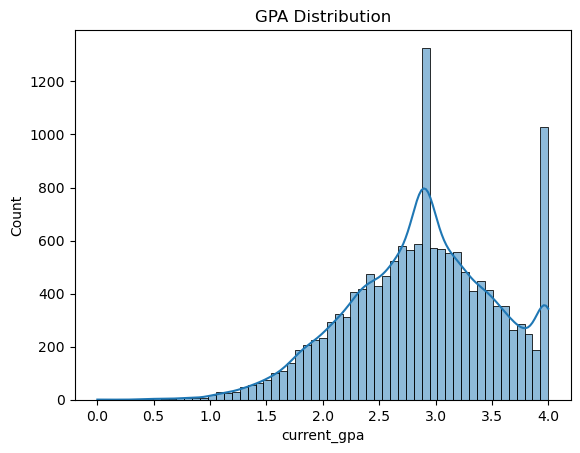

Skewness: -0.283985674487768


In [21]:
# Histogram
sns.histplot(df['current_gpa'], kde=True)
plt.title("GPA Distribution")
plt.show()

# Skewness value
print("Skewness:", skew(df['current_gpa']))

In [ ]:
# Normality Check
stat, p_normal = shapiro(df['current_gpa'].sample(5000))  # sample for large data

print("Shapiro p-value:", p_normal)

Shapiro p-value: 3.477237881606555e-24


p > 0.05   Use T-test     
p < 0.05  Use Mann-Whitney 

In [37]:
# GPA Category
df['gpa_category'] = pd.cut(
    df['current_gpa'],
    bins=[0, 2.0, 3.0, 4.0],
    labels=['Low', 'Medium', 'High']
)

# Low GPA Flag
df['low_gpa_flag'] = (df['current_gpa'] < 2.5).astype(int)

In [38]:
# Mean GPA by dropout
print(df.groupby('dropped_out')['current_gpa'].mean())

# Standard deviation
print(df.groupby('dropped_out')['current_gpa'].std())

dropped_out
0    2.942584
1    2.760904
Name: current_gpa, dtype: float64
dropped_out
0    0.600875
1    0.717909
Name: current_gpa, dtype: float64


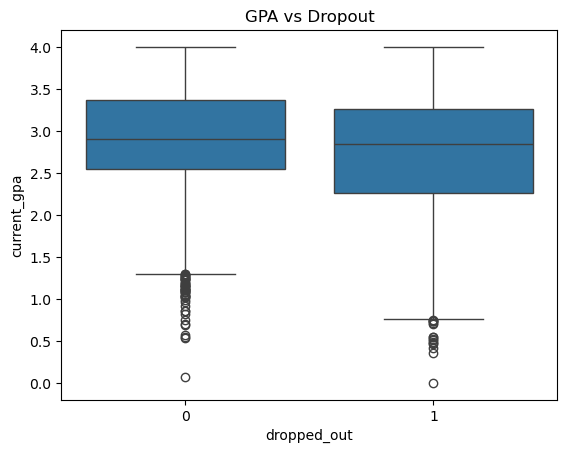

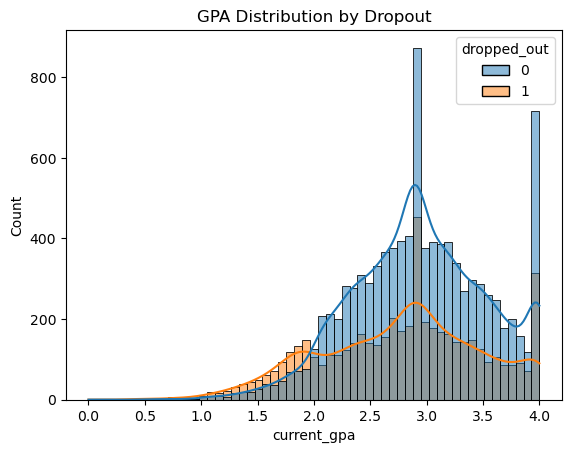

In [39]:
# Boxplot
sns.boxplot(x='dropped_out', y='current_gpa', data=df)
plt.title("GPA vs Dropout")
plt.show()

# Distribution comparison
sns.histplot(data=df, x='current_gpa', hue='dropped_out', kde=True)
plt.title("GPA Distribution by Dropout")
plt.show()

In [55]:
from scipy.stats import ttest_ind

dropout = df[df['dropped_out'] == 1]['current_gpa']
non_dropout = df[df['dropped_out'] == 0]['current_gpa']

t_stat, p_value = ttest_ind(dropout, non_dropout)

print("P-value:", p_value)

P-value: 1.5286663412787045e-60


In [53]:
if p_value < alpha:
    print("Reject Null Hypothesis → GPA significantly affects dropout")
else:
    print("Fail to Reject → GPA has no significant impact")

Reject Null Hypothesis → GPA significantly affects dropout


Hypothesis - 2
Students with lower attendance rates are more likely to drop out

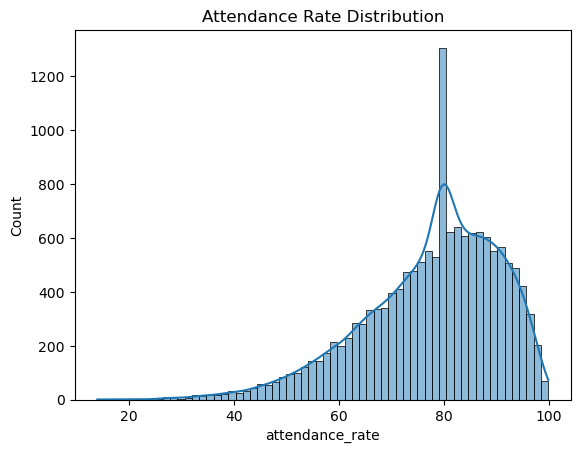

Skewness: -0.8316458796141579


In [56]:
# Distribution
sns.histplot(df['attendance_rate'], kde=True)
plt.title("Attendance Rate Distribution")
plt.show()

# Skewness
from scipy.stats import skew
print("Skewness:", skew(df['attendance_rate']))

In [ ]:
#Normality Check
stat, p_normal = shapiro(df['attendance_rate'].sample(5000))
print("Shapiro p-value:", p_normal)

Shapiro p-value: 9.461585100014653e-36


In [59]:
# Attendance Category
df['attendance_category'] = pd.cut(
    df['attendance_rate'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)

# Low attendance flag
df['low_attendance_flag'] = (df['attendance_rate'] < 75).astype(int)

In [60]:
# Mean attendance by dropout
print(df.groupby('dropped_out')['attendance_rate'].mean())

# Standard deviation
print(df.groupby('dropped_out')['attendance_rate'].std())

dropped_out
0    79.578009
1    74.337438
Name: attendance_rate, dtype: float64
dropped_out
0    11.765621
1    14.166797
Name: attendance_rate, dtype: float64


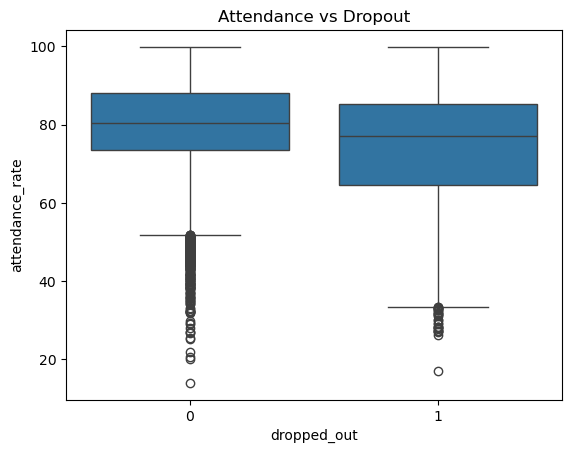

In [61]:
# Boxplot
sns.boxplot(x='dropped_out', y='attendance_rate', data=df)
plt.title("Attendance vs Dropout")
plt.show()

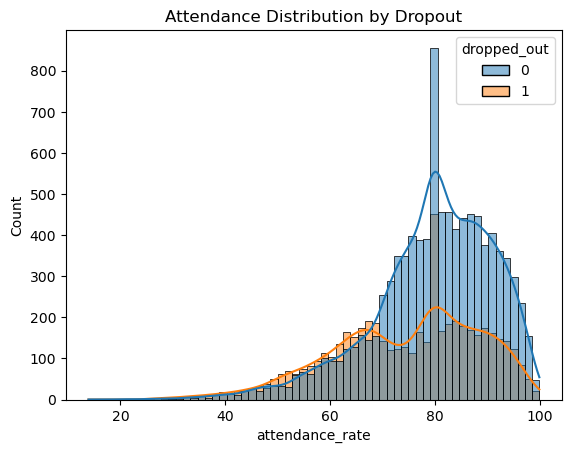

In [62]:
# Distribution comparison
sns.histplot(data=df, x='attendance_rate', hue='dropped_out', kde=True)
plt.title("Attendance Distribution by Dropout")
plt.show()

In [63]:
pd.crosstab(df['attendance_category'], df['dropped_out'], normalize='index') * 100

dropped_out,0,1
attendance_category,,
Low,44.186047,55.813953
Medium,62.412993,37.587007
High,71.604408,28.395592


In [64]:
dropout = df[df['dropped_out'] == 1]['attendance_rate']
non_dropout = df[df['dropped_out'] == 0]['attendance_rate']

t_stat, p_value = ttest_ind(dropout, non_dropout)

print("P-value:", p_value)

P-value: 5.165035519570128e-127


In [65]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null → Attendance significantly affects dropout")
else:
    print("Fail to Reject → No significant effect")

Reject Null → Attendance significantly affects dropout


Hypothesis - 3

Students with higher financial burden (loan amount) are more likely to drop out

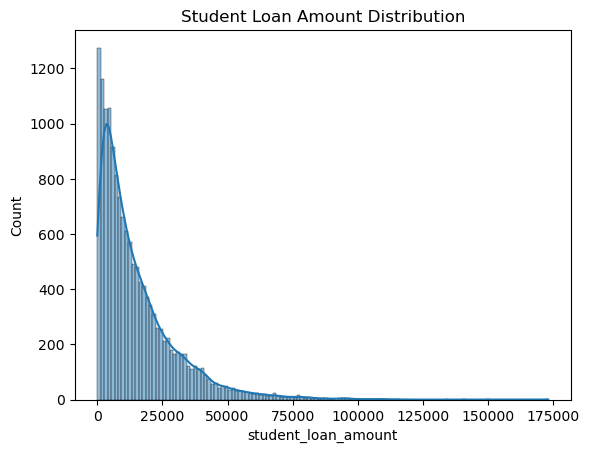

Skewness: 2.0710578018402357


In [66]:
# Distribution
sns.histplot(df['student_loan_amount'], kde=True)
plt.title("Student Loan Amount Distribution")
plt.show()

# Skewness
from scipy.stats import skew
print("Skewness:", skew(df['student_loan_amount']))

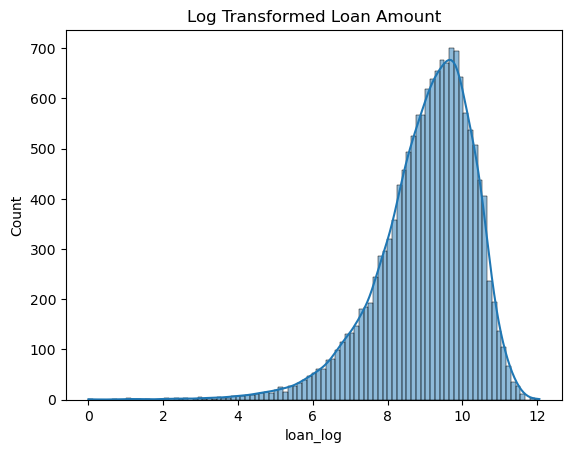

New Skewness: -1.1509242069632164


In [67]:
# Log transformation
df['loan_log'] = np.log1p(df['student_loan_amount'])

# Check again
sns.histplot(df['loan_log'], kde=True)
plt.title("Log Transformed Loan Amount")
plt.show()

print("New Skewness:", skew(df['loan_log']))

In [68]:
# normality check
stat, p_normal = shapiro(df['loan_log'].sample(5000))
print("Shapiro p-value:", p_normal)

Shapiro p-value: 2.43194664419819e-41


In [69]:
# Loan Category
df['loan_category'] = pd.cut(
    df['student_loan_amount'],
    bins=[0, 5000, 20000, 50000],
    labels=['Low', 'Medium', 'High']
)

# High loan flag
df['high_loan_flag'] = (df['student_loan_amount'] > 20000).astype(int)

In [70]:
# Mean loan by dropout
print(df.groupby('dropped_out')['student_loan_amount'].mean())

# Standard deviation
print(df.groupby('dropped_out')['student_loan_amount'].std())

dropped_out
0    14949.702736
1    14984.960212
Name: student_loan_amount, dtype: float64
dropped_out
0    15209.761352
1    15074.214931
Name: student_loan_amount, dtype: float64


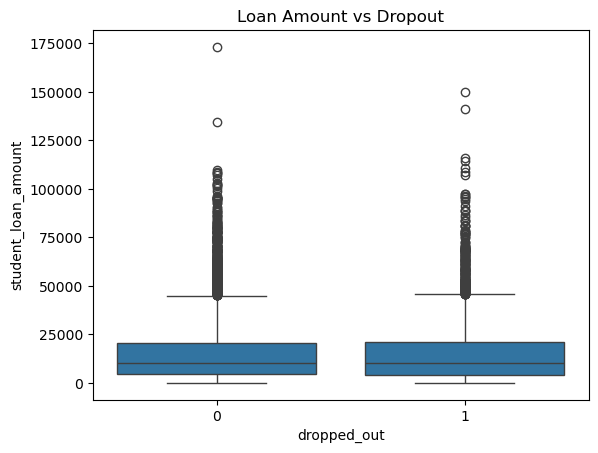

In [71]:
# Boxplot
sns.boxplot(x='dropped_out', y='student_loan_amount', data=df)
plt.title("Loan Amount vs Dropout")
plt.show()

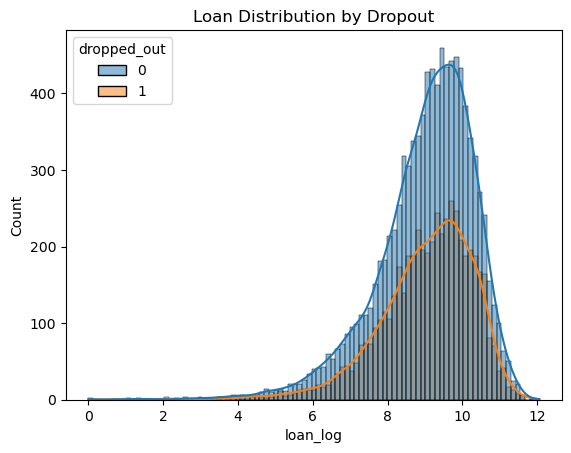

In [72]:
# Distribution comparison
sns.histplot(data=df, x='loan_log', hue='dropped_out', kde=True)
plt.title("Loan Distribution by Dropout")
plt.show()

In [73]:
pd.crosstab(df['loan_category'], df['dropped_out'], normalize='index') * 100

dropped_out,0,1
loan_category,,
Low,64.850452,35.149548
Medium,64.844904,35.155096
High,64.268868,35.731132


In [79]:
dropout = df[df['dropped_out'] == 1]['loan_log']
non_dropout = df[df['dropped_out'] == 0]['loan_log']

t_stat, p_value = ttest_ind(dropout, non_dropout)

print("P-value:", p_value)

P-value: 0.35345625877355713


In [80]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null → Financial burden significantly affects dropout")
else:
    print("Fail to Reject → No significant effect")

Fail to Reject → No significant effect


Hypothesis - 4

Students who fail more courses are more likely to drop out

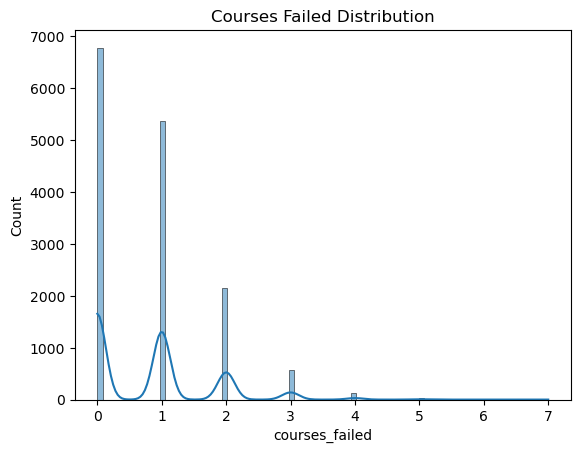

Skewness: 1.165294262088055


In [81]:
sns.histplot(df['courses_failed'], kde=True)
plt.title("Courses Failed Distribution")
plt.show()

from scipy.stats import skew
print("Skewness:", skew(df['courses_failed']))

In [82]:
# Category
df['fail_category'] = pd.cut(
    df['courses_failed'],
    bins=[-1, 0, 2, 10],
    labels=['None', 'Low', 'High']
)

# Flag
df['high_fail_flag'] = (df['courses_failed'] > 2).astype(int)

In [83]:
# Mean
print(df.groupby('dropped_out')['courses_failed'].mean())

# Std deviation
print(df.groupby('dropped_out')['courses_failed'].std())

dropped_out
0    0.688644
1    1.001516
Name: courses_failed, dtype: float64
dropped_out
0    0.810671
1    1.015326
Name: courses_failed, dtype: float64


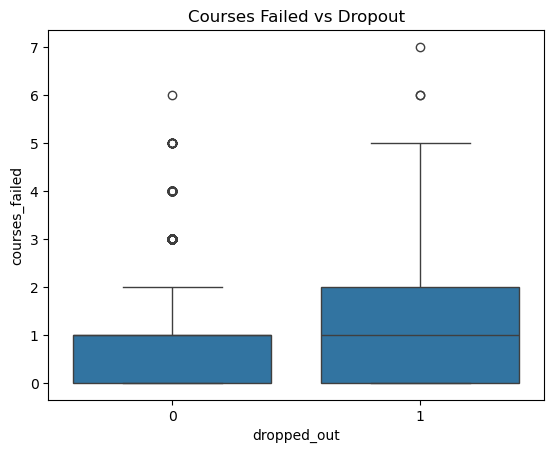

In [84]:
sns.boxplot(x='dropped_out', y='courses_failed', data=df)
plt.title("Courses Failed vs Dropout")
plt.show()

In [85]:
pd.crosstab(df['fail_category'], df['dropped_out'], normalize='index') * 100

dropped_out,0,1
fail_category,,
None,69.046916,30.953084
Low,63.044347,36.955653
High,43.197756,56.802244


In [90]:


dropout = df[df['dropped_out'] == 1]['courses_failed']
non_dropout = df[df['dropped_out'] == 0]['courses_failed']

t_stat, p_value = ttest_ind(dropout, non_dropout)

print("P-value:", p_value)

P-value: 4.738201539530237e-93


In [91]:
if p_value < 0.05:
    print("Reject Null → Course failure significantly affects dropout")
else:
    print("Fail to Reject → No significant effect")

Reject Null → Course failure significantly affects dropout


Hypothesis - 5

Students who study fewer hours per week are more likely to drop out

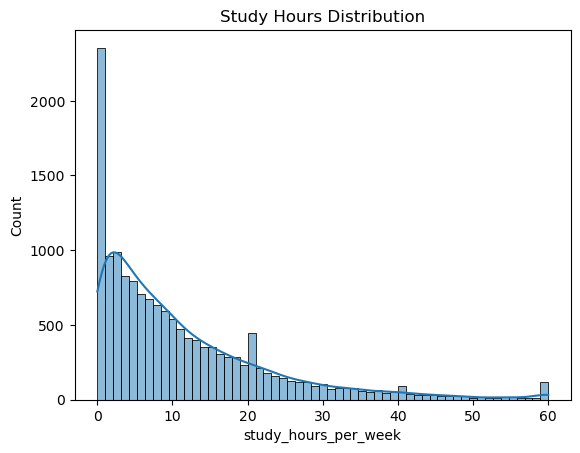

Skewness: 1.6965129053421821


In [92]:
sns.histplot(df['study_hours_per_week'], kde=True)
plt.title("Study Hours Distribution")
plt.show()

print("Skewness:", skew(df['study_hours_per_week']))

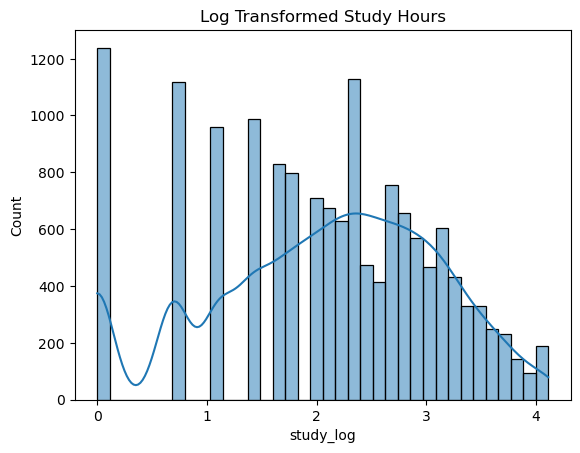

New Skewness: -0.3376606578167067


In [ ]:
df['study_log'] = np.log1p(df['study_hours_per_week'])

# Check again
sns.histplot(df['study_log'], kde=True)
plt.title("Log Transformed Study Hours")
plt.show()

print("New Skewness:", skew(df['study_log']))

In [104]:
df['study_sqrt'] = np.sqrt(df['study_hours_per_week'])

print("Sqrt Skewness:", skew(df['study_sqrt']))


Sqrt Skewness: 0.37564139488294407


In [105]:
from scipy.stats import boxcox

# Add 1 to avoid zero
df['study_boxcox'], _ = boxcox(df['study_hours_per_week'] + 1)

print("Box-Cox Skewness:", skew(df['study_boxcox']))

Box-Cox Skewness: -0.03573830154473852


In [102]:
pt = PowerTransformer(method='yeo-johnson')

df['study_yeojohnson'] = pt.fit_transform(df[['study_hours_per_week']])

print("Yeo-Johnson Skewness:", skew(df['study_yeojohnson']))

Yeo-Johnson Skewness: -0.03573831193271155


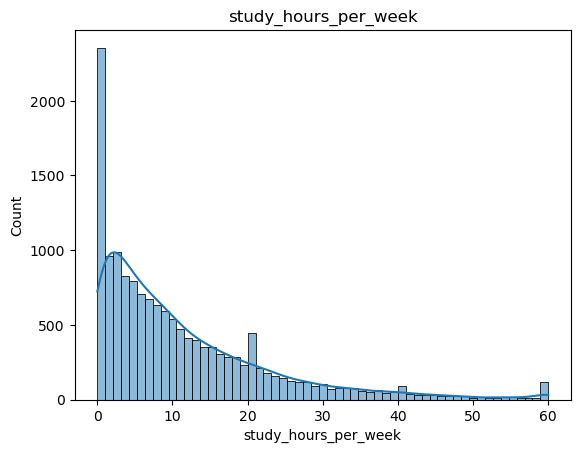

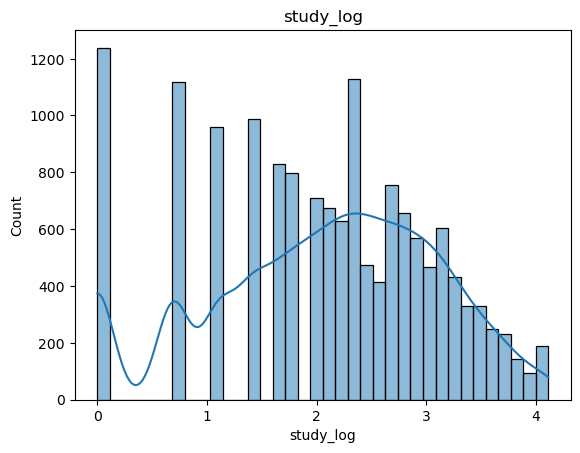

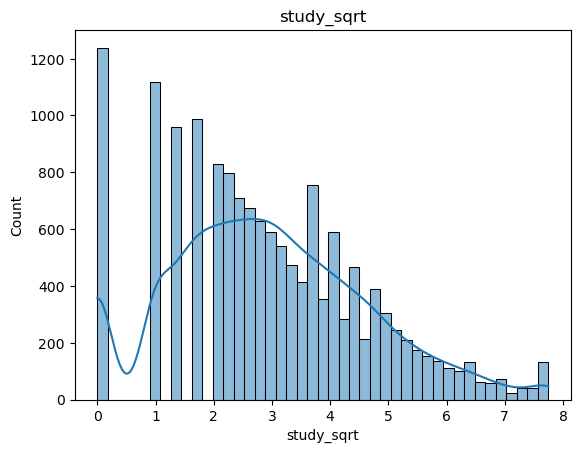

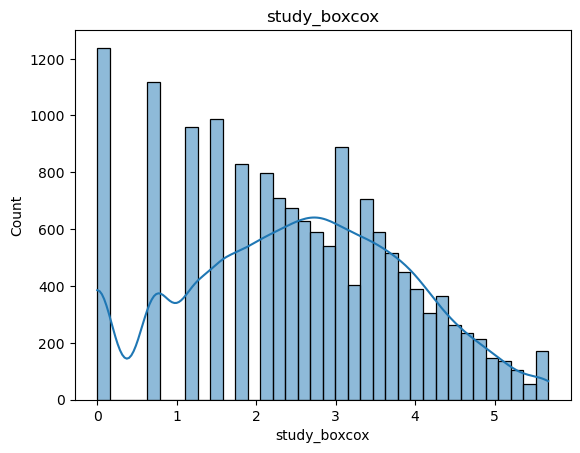

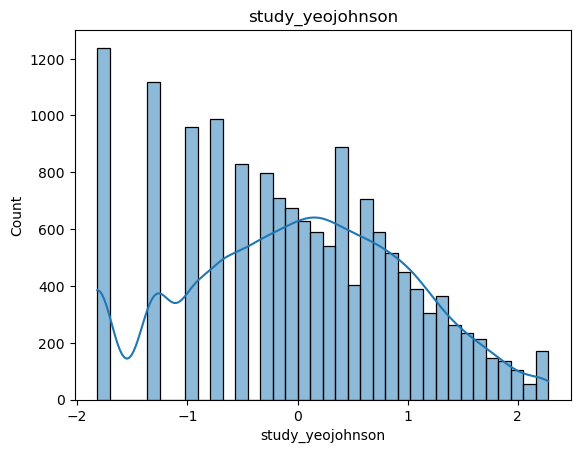

In [106]:

cols = ['study_hours_per_week', 'study_log', 'study_sqrt', 'study_boxcox', 'study_yeojohnson']

for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [107]:
print("Log Skewness:", skew(df['study_log']))
print("Sqrt Skewness:", skew(df['study_sqrt']))
print("Box-Cox Skewness:", skew(df['study_boxcox']))
print("Yeo-Johnson Skewness:", skew(df['study_yeojohnson']))

Log Skewness: -0.3376606578167067
Sqrt Skewness: 0.37564139488294407
Box-Cox Skewness: -0.03573830154473852
Yeo-Johnson Skewness: -0.03573831193271155


In [109]:
best_col = 'study_yeojohnson'  

In [108]:
# Category
df['study_category'] = pd.cut(
    df['study_hours_per_week'],
    bins=[0, 10, 20, 60],
    labels=['Low', 'Medium', 'High']
)

# Flag
df['low_study_flag'] = (df['study_hours_per_week'] < 10).astype(int)

In [110]:
# Mean
print(df.groupby('dropped_out')[best_col].mean())

# Std deviation
print(df.groupby('dropped_out')[best_col].std())

dropped_out
0    0.087248
1   -0.160709
Name: study_yeojohnson, dtype: float64
dropped_out
0    0.975763
1    1.024078
Name: study_yeojohnson, dtype: float64


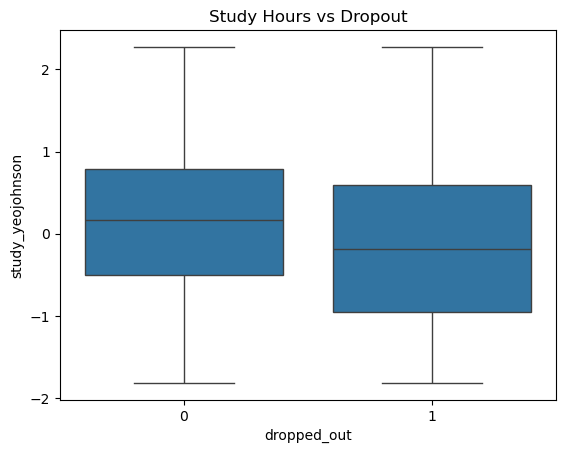

In [111]:
sns.boxplot(x='dropped_out', y=best_col, data=df)
plt.title("Study Hours vs Dropout")
plt.show()

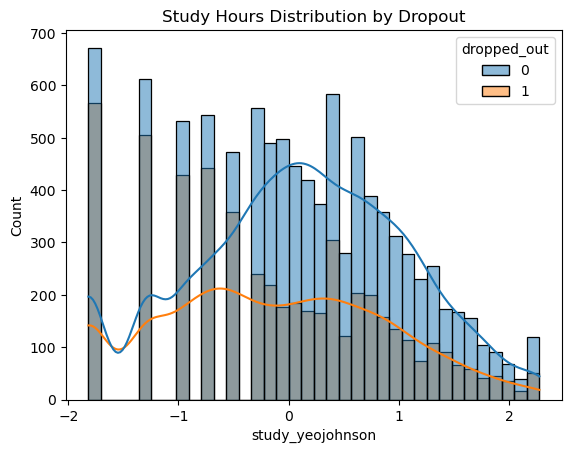

In [112]:
sns.histplot(data=df, x=best_col, hue='dropped_out', kde=True)
plt.title("Study Hours Distribution by Dropout")
plt.show()

In [113]:
dropout = df[df['dropped_out'] == 1][best_col]
non_dropout = df[df['dropped_out'] == 0][best_col]

t_stat, p_value = ttest_ind(dropout, non_dropout)

print("P-value:", p_value)

P-value: 5.631495410051835e-48


In [115]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null → Study hours significantly affect dropout")
else:
    print("Fail to Reject → No significant effect")

Reject Null → Study hours significantly affect dropout
